# Sprint3 Part1 머신러닝 기초
> 목표: 학습 데이터 특징 및 주요 모델 경험  
> 내용: 전반적인 학습 데이터 전처리 및 모델 성능평가

----
# EDA & 데이터 전처리
> **Exploratory Data Analysis**(탐색적 데이터 분석)  
데이터를 본격적으로 모델링하기 전에
데이터의 구조, 분포, 이상치, 변수 간 관계 등을 탐색하는 과정이다.  
데이터의 특성을 이해하고, 분석 방향을 설정하기 위한 사전 단계  

> **데이터 전처리**  
데이터를 모델이 학습하기 좋은 구조로 전처리하는 과정

## 데이터 불러오기 및 정보 확인

In [ ]:
# 데이터 불러오기
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

url = "https://raw.githubusercontent.com/rngus4656/datasets/refs/heads/main/S2/titanic.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 기본정보 확인

In [ ]:
print(df.shape)
df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.describe(exclude='number')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


### 결측치 & 중복 확인

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering  
> 모델의 학습을 위한 데이터 전처리 단계

### 데이터 누수 방지 및 미사용 칼럼 제거
> 식별자 정보(ID, 고유번호)를 가진 칼럼은 데이터 누수의 위험이 크기때문에 반드시 제거해 준다.

In [ ]:
# 원본 수정을 방지하기 위한 copy 생성
df_2 = df.copy()

# 데이터 누수 방지를 위한 식별자 제거 및 불필요 칼럼 제거
df_2 = df_2.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

### 결측치 처리

In [ ]:
# Age 결측치 - Sex, Pclass를 기준으로한 중앙값으로 대체
df_2['Age'] = df_2['Age'].fillna(df_2.groupby(['Sex', 'Pclass'])['Age'].transform('median'))
# Embarked - 최빈값 mode()로 대체
df_2['Embarked'] = df_2['Embarked'].fillna(df_2['Embarked'].mode()[0])

# 결측치 재확인
df_2.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


### 칼럼 생성 및 변환

In [ ]:
# Age_null 칼럼을 생성하여 원래의 결측치 여부 판단
df_2['Age_null'] = df_2['Age'].isna().astype(int)

# 나이를 구간화한 카테고리 칼럼 생성
age_bins = [0, 12, 19, 34, 58, 100]
age_cat = ['Child', 'Teen', 'Young', 'Adult', 'Senior']
AgeGroup = pd.cut(df_2['Age'], bins=age_bins, labels=age_cat)
df_2['AgeGroup'] = AgeGroup

## 학습 데이터 전처리
> 문자열, 범주형 값을 모델이 인식하지 못하는 이유로  
> 학습에 적절한 인코딩, 스케일링 방식으로 학습 데이터 값 전처리

### 학습 데이터 셋 분리
> 학습 및 평가를 위한 데이터 셋을 분리한다.  
> 반드시 fit_transform이 필요한 인코딩, 스케일링작업 전에 분리한다.

In [ ]:
# 독립변수 X, 종속변수 y 분리
X = df_2.drop('Survived', axis=1) # 학습할 독립변수 X
y = df_2['Survived'] # 예측해야할 종속변수 y
X.shape, y.shape

((891, 9), (891,))

In [ ]:
# train(문제집 학습), val(모의고사), test(수능)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
X_train.shape, X_val.shape, X_test.shape

((569, 9), (143, 9), (179, 9))

### 인코딩 및 스케일링

In [ ]:
# 범주형 칼럼, 수치형 칼럼 변수 지정
cat_cols = X.select_dtypes(exclude='number').columns
num_cols = X.select_dtypes(include='number').columns
cat_cols, num_cols

(Index(['Sex', 'Embarked', 'AgeGroup'], dtype='object'),
 Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_null'], dtype='object'))

#### 범주형 인코딩 One-Hot Encording
> 가장 대표적인 인코딩 방식으로, 범주형 값에 해당하는 칼럼을 생성하여 0, 1 이진분류 값으로 대체한다.  

In [ ]:
# 차원이 지나치게 많아지면 다중 공선성, 차원의 저주 문제가 생길 수 있다.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_val_ohe = ohe.transform(X_val[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])
X_train_ohe.shape, X_val_ohe.shape, X_test_ohe.shape # 기존 범주형 칼럼이 3열에서 10열로 증가함

((569, 10), (143, 10), (179, 10))

In [ ]:
# 인코딩 결과 데이터프레임으로 저장
ohe_cat_cols = ohe.get_feature_names_out(cat_cols)
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cat_cols)
X_val_ohe = pd.DataFrame(X_val_ohe, columns=ohe_cat_cols)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cat_cols)
X_train_ohe.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,AgeGroup_Adult,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teen,AgeGroup_Young
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### 수치형 스케일링
> 각 칼럼의 대소 규격이 다르기 때문에, 표준화된 수치로 스케일링 한다.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_val_scaled = scaler.transform(X_val[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_cols)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=num_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_cols)
X_train_scaled.head()

,Pclass,Age,SibSp,Parch,Fare,Age_null
0,-0.369051,-0.041451,-0.462989,-0.461079,-0.453710,0.0
1,-0.369051,0.485028,0.481243,1.860636,-0.071871,0.0
2,0.830891,-0.943985,0.481243,-0.461079,-0.529985,0.0
3,-0.369051,-0.492718,-0.462989,-0.461079,-0.398371,0.0
4,-0.369051,-0.793563,-0.462989,-0.461079,-0.398371,0.0


#### 인코딩 + 스케일링 데이터 합치기
> 각각 따로 전처리 된 칼럼을 하나의 학습 데이터 셋으로 다시 합친다.

In [ ]:
X_tr_fin = pd.concat([X_train_ohe, X_train_scaled],axis=1)
X_va_fin = pd.concat([X_val_ohe, X_val_scaled],axis=1)
X_te_fin = pd.concat([X_test_ohe, X_test_scaled],axis=1)
X_tr_fin.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,AgeGroup_Adult,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teen,AgeGroup_Young,Pclass,Age,SibSp,Parch,Fare,Age_null
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.369051,-0.041451,-0.462989,-0.461079,-0.453710,0.0
1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,-0.369051,0.485028,0.481243,1.860636,-0.071871,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.830891,-0.943985,0.481243,-0.461079,-0.529985,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.369051,-0.492718,-0.462989,-0.461079,-0.398371,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.369051,-0.793563,-0.462989,-0.461079,-0.398371,0.0


---------
# 모델 학습 및 테스트

## 의사 결정 나무 (DT)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# DT 모델 생성 max_depth=트리모델의 최대 깊이
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

# 학습
dt.fit(X_tr_fin, y_train)
# 예측
dt_pred = dt.predict(X_te_fin)

# 정확도
print("DT Accuracy:", accuracy_score(y_test, dt_pred))

DT Accuracy: 0.7877094972067039


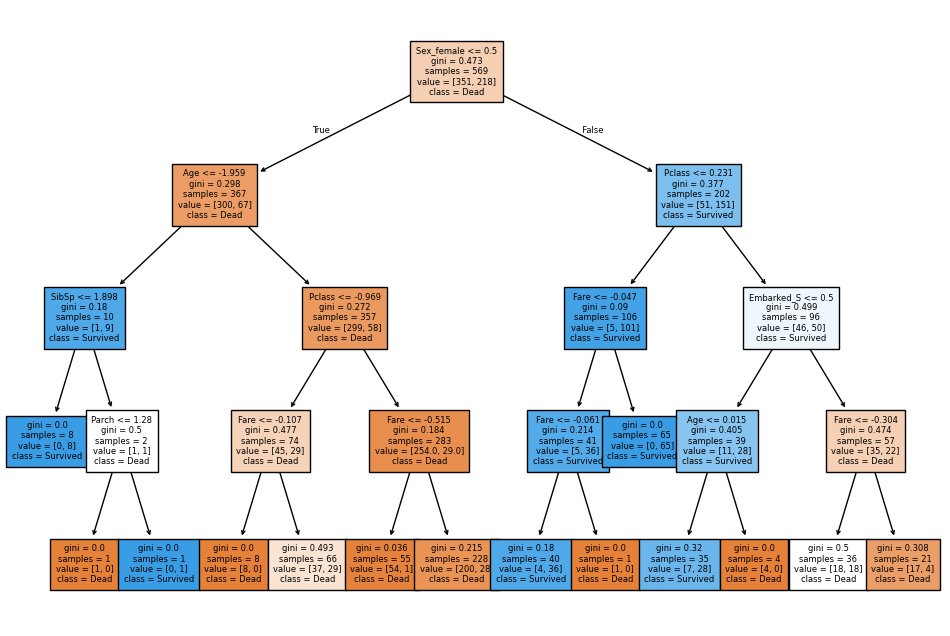

In [ ]:
# 판단 기준을 확인할 수 있다.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(dt,feature_names=X_tr_fin.columns,class_names=['Dead','Survived'], filled=True, fontsize=6)
plt.show()

## 랜덤 포레스트 (RF)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=트리 개수, max_depth=트리 최대 깊이
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

# 학습
rf.fit(X_tr_fin, y_train)
# 예측
rf_pred = rf.predict(X_te_fin)
# 정확도
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 0.7988826815642458


## XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, max_depth=8, random_state=42)

# 학습
xgb.fit(X_tr_fin, y_train)
# 예측
xgb_pred = xgb.predict(X_te_fin)
# 정확도
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))

XGB Accuracy: 0.7877094972067039


-----
# 성능평가

## 분류모델 성능평가 지표
✓  정확도, 정밀도, 재현율, f-1 score  
•  Accuracy(정확도): 전체 중 맞춘 비율  
•  Precision(정밀도): 모델이 예측한 값이 정답인 비율  
•  Recall(재현율): 실제값 중 모델이 제대로 예측한 비율  
•  f1-score: Precision과 Recall의 조화 평균  

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# DT
dt_pred = dt.predict(X_te_fin)
print("DT Accuracy:", accuracy_score(y_test, dt_pred))

# RF
rf_pred = rf.predict(X_te_fin)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

# XGB
xgb_pred = xgb.predict(X_te_fin)
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))

DT Accuracy: 0.7877094972067039
RF Accuracy: 0.7988826815642458
XGB Accuracy: 0.7877094972067039


In [ ]:
print("DT\n", classification_report(y_test, dt_pred))
print("RF\n", classification_report(y_test, rf_pred))
print("XGB\n", classification_report(y_test, xgb_pred))

DT
               precision    recall  f1-score   support

           0       0.77      0.94      0.84       110
           1       0.84      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.76       179
weighted avg       0.80      0.79      0.78       179

RF
               precision    recall  f1-score   support

           0       0.79      0.91      0.85       110
           1       0.81      0.62      0.70        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

XGB
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       110
           1       0.72      0.72      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## 회귀모델 성능평가 지표
✓  MAE (Mean Absolute Error): 오차 절대값 평균  
    •  실제값과 예측값의 오차 절대값을 평균으로 함  
    •  음수가 섞여있을 경우 연산에 영향이 가지않도록 절대값을 사용  
    •  맨해튼(Manhattan) 거리라고도 불리우며 계단식 접근 방식  

✓  RMSE (Root Mean Squared Error): 제곱 평균 오차의 제곱근  
    •  실제값과 예측값의 오차를 제곱하여 평균을낸 제곱근의 값  
    •  유클리디안(Euclidean) 거리라고도 불리우며 직선적 접근 방식   
    •  대부분의 회귀 모델에서 MAE보다 RMSE를 채택함  

✓  R² Score (결정계수)  
    •  모델이 실제 데이터의 변동성을 얼마나 잘 설정하는지 나타내는 값  
    •  값의 범위는 0~1, 1에 가까울수록 데이터를 잘 설명  


## Feature Importance 확인하기  

> Feature Importance
- 트리 기반 모델에서 불순도 감소량을 기준으로 계산되는 변수 중요도
- 여러 트리의 중요도를 평균하여 산출
- 연속형 변수나 범주 수가 많은 변수에 편향될 수 있음

In [ ]:
import matplotlib.pyplot as plt

def plot_feature_importance_subplot(models, X, model_names):

    fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 6))

    if len(models) == 1:
        axes = [axes]

    for ax, model, name in zip(axes, models, model_names):

        fi = pd.Series(model.feature_importances_,
                       index=X.columns).sort_values(ascending=False).head(20)

        fi.plot(kind="barh", ax=ax)

        ax.set_title(f"{name} Feature Importance")
        ax.set_xlabel("Importance")

        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

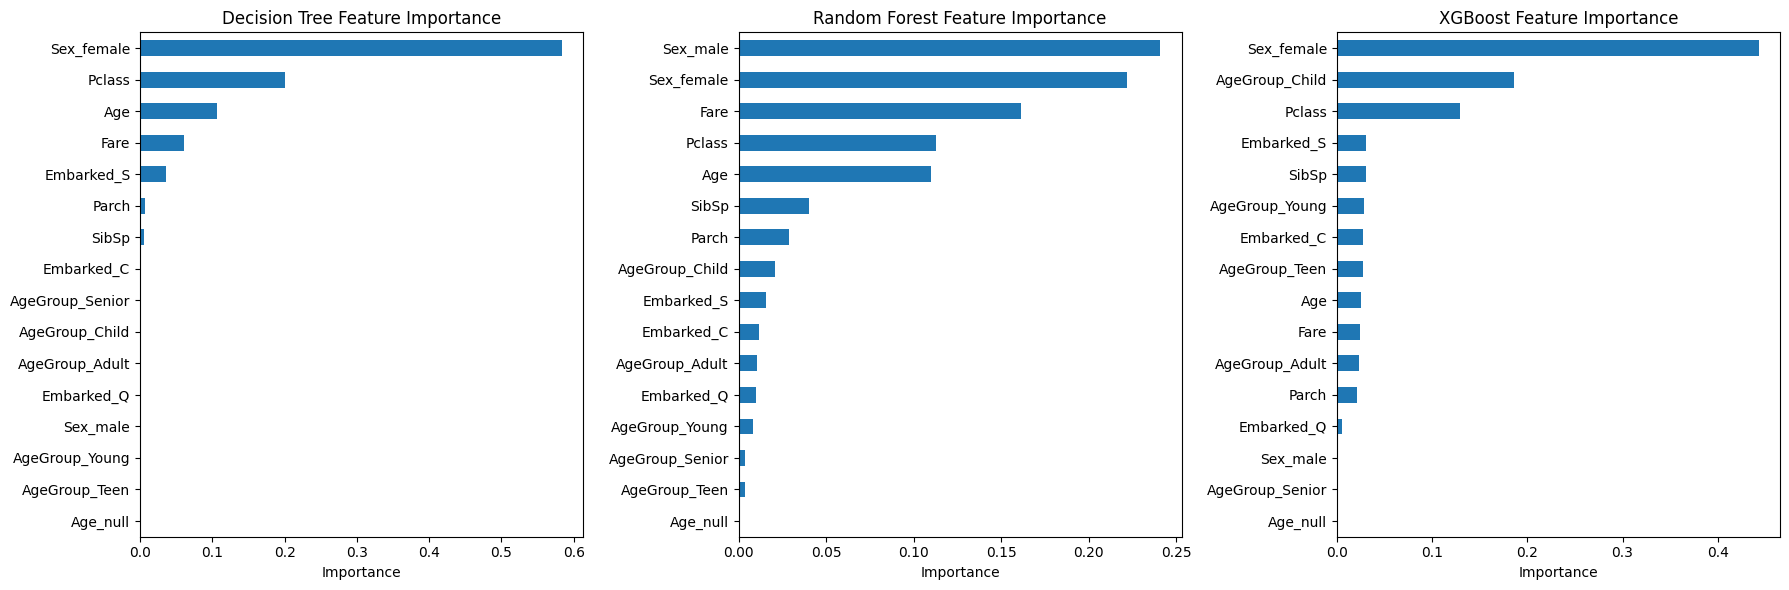

In [ ]:
models = [dt, rf, xgb]
names = ["Decision Tree", "Random Forest", "XGBoost"]

plot_feature_importance_subplot(models, X_tr_fin, names)

## Permutation Importance 확인하기

> Permutation Importance
- 특정 변수를 무작위로 섞었을 때 모델 성능 감소량으로 중요도 측정
- 모델 재학습 없이 계산 가능, Feature Importance보다 신뢰도가 높은편
- 변수 간 상관관계가 높으면 왜곡될 수 있음

In [ ]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance_subplot(models, X_val, y_val, model_names):

    fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 6))

    if len(models) == 1:
        axes = [axes]

    for ax, model, name in zip(axes, models, model_names):

        result = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )

        perm_importance = pd.Series(
            result.importances_mean,
            index=X_val.columns
        ).sort_values(ascending=False).head(20)

        perm_importance.plot(kind="barh", ax=ax)

        ax.set_title(f"{name} Permutation Importance")
        ax.set_xlabel("Mean Decrease in Score")

        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

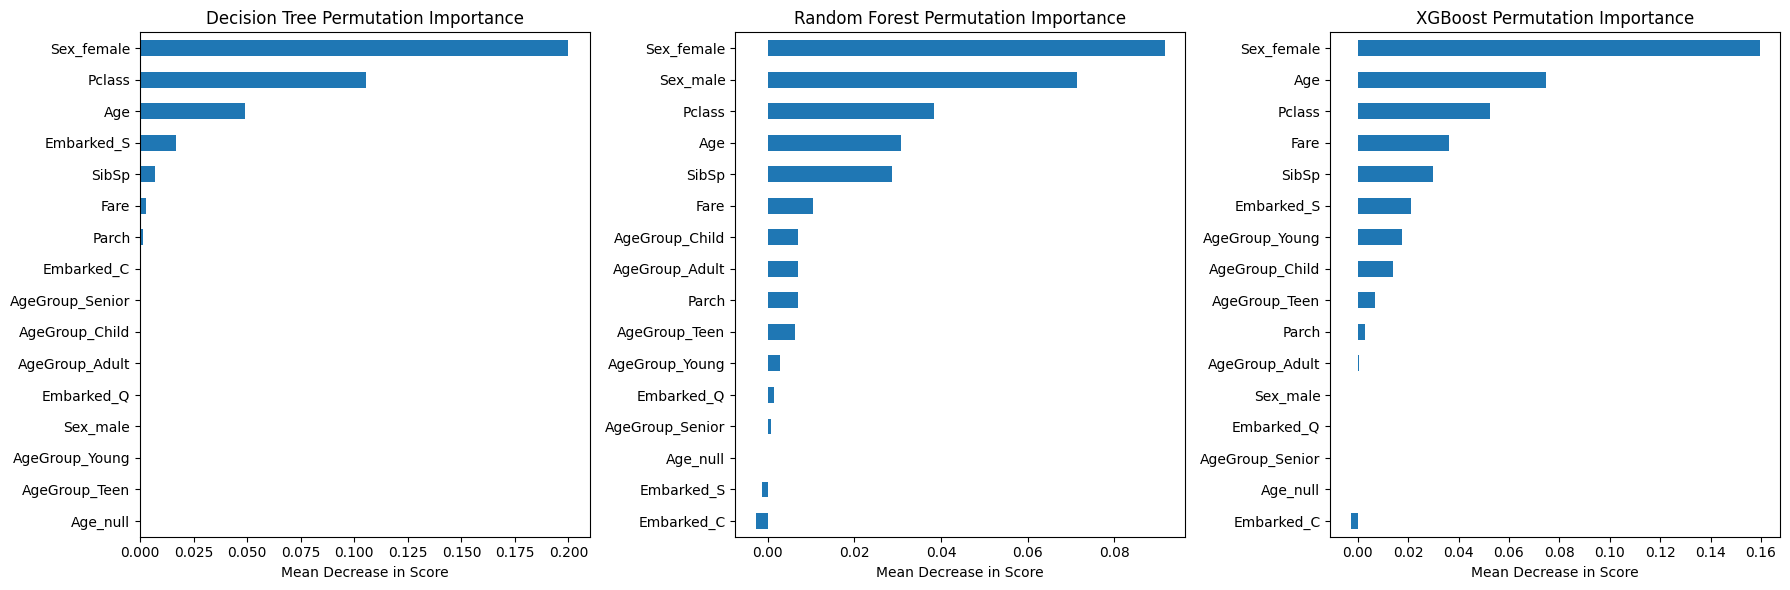

In [ ]:
models = [dt, rf, xgb]
names = ["Decision Tree", "Random Forest", "XGBoost"]

plot_permutation_importance_subplot(models, X_va_fin, y_val, names)

----
# APPENDIX) 비지도학습 주성분 분석(PCA), K-means 클러스터링(군집화)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 데이터 불러오기
df = pd.read_csv("https://raw.githubusercontent.com/rngus4656/datasets/refs/heads/main/S2/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# 데이터셋 분리, 스케일링
X = df.drop("species", axis=1)
y = df["species"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# PCA 차원 축소
n_components = 4
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# PCA 결과 DataFrame 생성
pca_cols = [f'PC{i+1}' for i in range(n_components)]
pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=df.index)

# 기존 df에 추가
df_pca = pd.concat([df, pca_df], axis=1)

df_pca.head()

,sepal_length,sepal_width,petal_length,petal_width,species,PC1,PC2,PC3,PC4
0,5.1,3.5,1.4,0.2,setosa,-2.264703,0.480027,0.127706,-0.024168
1,4.9,3.0,1.4,0.2,setosa,-2.080961,-0.674134,0.234609,-0.103007
2,4.7,3.2,1.3,0.2,setosa,-2.364229,-0.341908,-0.044201,-0.028377
3,4.6,3.1,1.5,0.2,setosa,-2.299384,-0.597395,-0.091290,0.065956
4,5.0,3.6,1.4,0.2,setosa,-2.389842,0.646835,-0.015738,0.035923


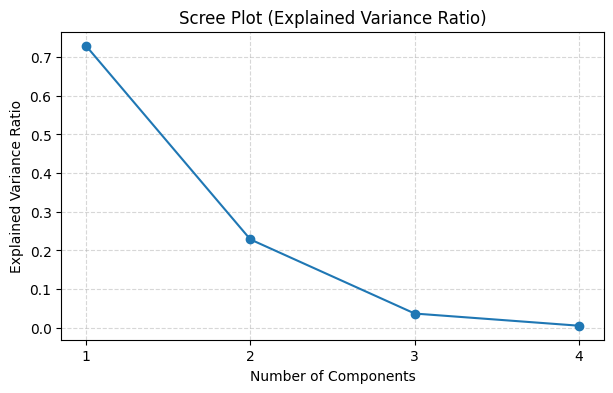

In [ ]:
# Scree Plot으로 PCA 엘보우 포인트 확인
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# 설명분산비율
evr = pca_full.explained_variance_ratio_

# 컴포넌트 번호
components = np.arange(1, len(evr) + 1)

# Scree Plot
plt.figure(figsize=(7,4))
plt.plot(components, evr, marker='o')
plt.xticks(components)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (Explained Variance Ratio)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

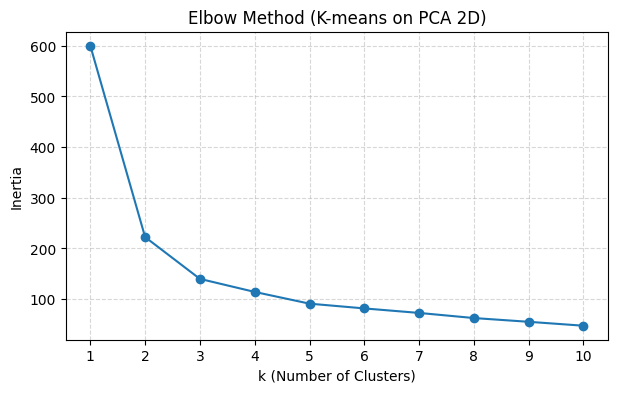

In [ ]:
# K-means 군집화 엘보우 포인트 확인

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(k_range), inertias, marker='o')
plt.xticks(list(k_range))
plt.xlabel("k (Number of Clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method (K-means on PCA 2D)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

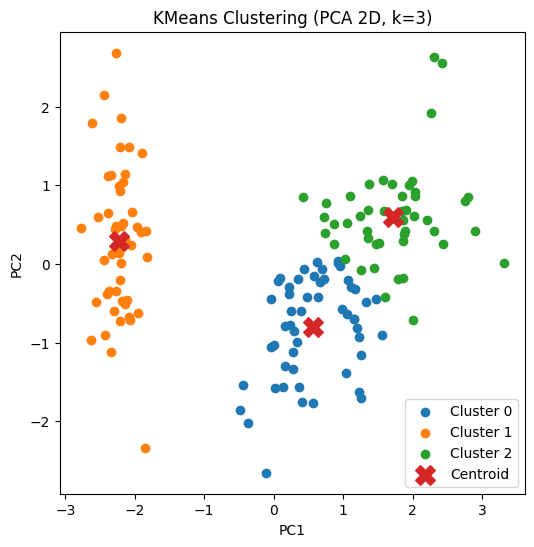

In [ ]:
# k개의 군집화

k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(6,6))
for cid in range(k):
    plt.scatter(X_pca[labels == cid, 0], X_pca[labels == cid, 1], label=f"Cluster {cid}")

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker="X", s=200, label="Centroid")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clustering (PCA 2D, k={k})")
plt.legend()
plt.show()

In [ ]:
df_cluster = df.copy()
df_cluster["cluster"] = labels
df_cluster.sample(10, random_state=42)

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
73,6.1,2.8,4.7,1.2,versicolor,0
18,5.7,3.8,1.7,0.3,setosa,1
118,7.7,2.6,6.9,2.3,virginica,2
78,6.0,2.9,4.5,1.5,versicolor,0
76,6.8,2.8,4.8,1.4,versicolor,2
31,5.4,3.4,1.5,0.4,setosa,1
64,5.6,2.9,3.6,1.3,versicolor,0
141,6.9,3.1,5.1,2.3,virginica,2
68,6.2,2.2,4.5,1.5,versicolor,0
82,5.8,2.7,3.9,1.2,versicolor,0


In [ ]:
compare = pd.DataFrame({"species": y, "cluster": labels})
compare.groupby(["species", "cluster"]).size().unstack(fill_value=0)

cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36
